In [18]:
# Installing packages and Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

data = pd.read_csv('../data/kyle_schwarber_full_data.csv')
data['hits'] = data['events'].isin(['single', 'double', 'triple', 'home_run'])
data['zone'] = data['zone'].astype('category')
data['pitch_number'] = data['pitch_number'].astype('category')
data['pitch_count'] = data['balls'].astype(str) + '-' + data['strikes'].astype(str)

features = ['zone', 'p_throws', 'pitch_count', 'effective_speed', 'release_spin_rate', 'pitch_number', 'pitch_name', 'hits']
data = data[features]
data = data.dropna()

In [31]:
# Plot Code:
from matplotlib.lines import Line2D
target_map = {str(i): f"Cluster {i}" for i in range(10)}

def plot_cluster_embedding(embedding, cluster_labels, title, x_label="Component 1", y_label="Component 2"):
    cluster_ids = np.asarray(cluster_labels, dtype=int)
    unique_clusters = np.unique(cluster_ids)
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=cluster_ids,
        cmap="tab10",
        s=6,
        alpha=0.5,
    )
    handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="",
            markerfacecolor=scatter.cmap(scatter.norm(cluster_id)),
            markeredgecolor="none",
            markersize=6,
            alpha=0.8,
        )
        for cluster_id in unique_clusters
    ]
    legend_labels = [f"Cluster {cluster_id}" for cluster_id in unique_clusters]
    plt.legend(handles, legend_labels, title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.tight_layout()

In [20]:
X = pd.DataFrame(data.drop(columns=['hits']))
y = pd.Series(data['hits'], name='target')

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 307, stratify = y)


from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.cluster import KMeans

num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('classifier', KMeans(n_clusters = 10, random_state = 307))
])

X_transformed = model.fit_transform(X_train)
kmeans_labels = model.named_steps['classifier'].labels_

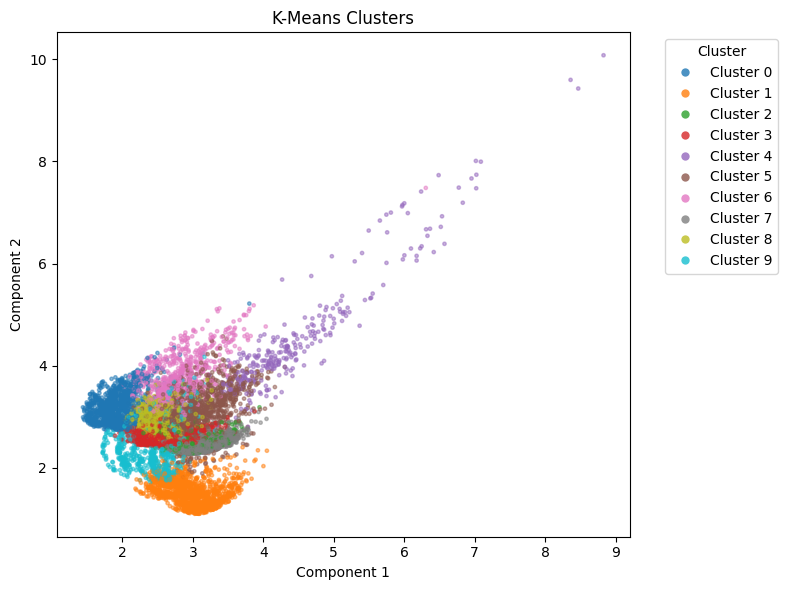

In [32]:
plot_cluster_embedding(X_transformed, kmeans_labels,  title="K-Means Clusters")